In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout, BatchNormalization
from keras.regularizers import l1_l2
from keras.optimizers import Adam, RMSprop, SGD
from keras.callbacks import EarlyStopping

from imblearn.over_sampling import SMOTE
import optuna

In [ ]:
# Load Dataset

In [2]:
df = pd.read_csv(r"C:\Users\chinn\Downloads\archive (7)\adult.csv")

In [3]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [ ]:
# Basic EDA

In [4]:
df.shape

(48842, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [6]:
df.duplicated().sum()

np.int64(52)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [9]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == '?').sum()
    if count > 0:
        print(f"{col}: {count} missing values")

workclass: 2795 missing values
occupation: 2805 missing values
native-country: 856 missing values


In [10]:
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

In [11]:
df.isnull().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [ ]:
# Handle Missing Values

In [12]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

C:\Users\chinn\AppData\Local\Temp\ipykernel_39104\2422164989.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [13]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [14]:
# Drop unnecessary columns
df.drop(columns=['fnlwgt', 'education'], inplace=True)

# Optional
# df.drop(columns=['native-country'], inplace=True)

In [15]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print(num_cols)

Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')


In [16]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

age: 215 outliers
educational-num: 1787 outliers
capital-gain: 4035 outliers
capital-loss: 2282 outliers
hours-per-week: 13486 outliers


In [17]:
# Handle Outliers Using Capping (Winsorization)
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [19]:
# Target Variable
print(df['income'].value_counts())
print()
print(df['income'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

income
<=50K    37109
>50K     11681
Name: count, dtype: int64

income
<=50K    76.06%
>50K     23.94%
Name: proportion, dtype: object


C:\Users\chinn\AppData\Local\Temp\ipykernel_39104\1595504016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='income', data=df, palette='Set2')


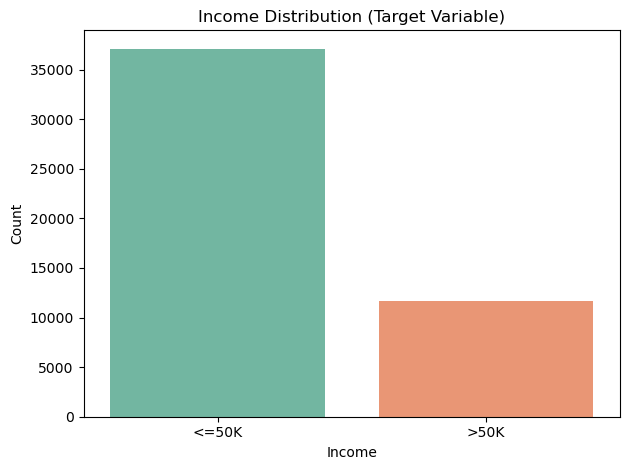

In [20]:
sns.countplot(x='income', data=df, palette='Set2')
plt.title('Income Distribution (Target Variable)')
plt.xlabel('Income')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [21]:
# encode target column
df["income"] = df["income"].map({
    "<=50K":0,
    ">50K":1,
    "<=50K.":0,
    ">50K.":1
})

In [22]:
df['income'].value_counts()

income
0    37109
1    11681
Name: count, dtype: int64

In [23]:
# separate features and target
X = df.drop(columns=['income'])
y = df['income']
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (48790, 12)
y shape: (48790,)


In [24]:
# Train-Test Split
X_train_full, X_test, y_train_full, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [25]:
# Validation Split
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.2,random_state=42,stratify=y_train_full)

In [26]:
# Numerical and Categorical Columns
num_cols = X.select_dtypes(exclude='object').columns.tolist()
cat_cols = X.select_dtypes(include='object').columns.tolist()

print("Numeric columns :", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns : ['age', 'educational-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical columns: ['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'native-country']


In [27]:
# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[("Scaling", MinMaxScaler(), num_cols),
                  ("Encoding",OneHotEncoder(drop="first", handle_unknown="ignore"),cat_cols)])

In [28]:
# Transform Data
X_train_t = preprocessor.fit_transform(X_train)
X_val_t = preprocessor.transform(X_val)
X_test_t = preprocessor.transform(X_test)

C:\Users\chinn\AppData\Roaming\Python\Python313\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [6] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [29]:
X_train_t.shape

(31225, 80)

In [30]:
# Baseline ANN (Before smote)
model = Sequential([
    Input(shape=(X_train_t.shape[1],)),
    Dense(32, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,769 (18.63 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
early = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train_t, y_train,
          epochs=50,
          validation_data=(X_val_t, y_val),
          batch_size=256,
          callbacks=[early],
          verbose=2)

Epoch 1/50
122/122 - 3s - 27ms/step - accuracy: 0.7889 - loss: 0.4520 - val_accuracy: 0.8281 - val_loss: 0.3777
Epoch 2/50
122/122 - 1s - 8ms/step - accuracy: 0.8294 - loss: 0.3626 - val_accuracy: 0.8322 - val_loss: 0.3625
Epoch 3/50
122/122 - 1s - 7ms/step - accuracy: 0.8341 - loss: 0.3524 - val_accuracy: 0.8341 - val_loss: 0.3564
Epoch 4/50
122/122 - 1s - 7ms/step - accuracy: 0.8364 - loss: 0.3481 - val_accuracy: 0.8358 - val_loss: 0.3534
Epoch 5/50
122/122 - 1s - 8ms/step - accuracy: 0.8366 - loss: 0.3463 - val_accuracy: 0.8353 - val_loss: 0.3520
Epoch 6/50
122/122 - 1s - 7ms/step - accuracy: 0.8376 - loss: 0.3446 - val_accuracy: 0.8378 - val_loss: 0.3514
Epoch 7/50
122/122 - 1s - 6ms/step - accuracy: 0.8383 - loss: 0.3437 - val_accuracy: 0.8390 - val_loss: 0.3509
Epoch 8/50
122/122 - 1s - 6ms/step - accuracy: 0.8388 - loss: 0.3422 - val_accuracy: 0.8378 - val_loss: 0.3507
Epoch 9/50
122/122 - 1s - 6ms/step - accuracy: 0.8385 - loss: 0.3416 - val_accuracy: 0.8392 - val_loss: 0.3493


In [32]:
y_pred_base = np.where(model.predict(X_test_t) > 0.5, 1, 0)
print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Baseline Accuracy: 0.8366468538634966


In [ ]:
# Handle class Imbalance with smote

In [33]:
print("Before SMOTE:", pd.Series(y_train).value_counts().to_dict())

smote = SMOTE(random_state=21)
X_train_res, y_train_res = smote.fit_resample(X_train_t, y_train)

print("After SMOTE :", pd.Series(y_train_res).value_counts().to_dict())

Before SMOTE: {0: 23749, 1: 7476}
After SMOTE : {0: 23749, 1: 23749}


In [ ]:
# hyperparameter Tunning with optuna

In [34]:
def objective(trial):
    lr_rate        = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    n_layers       = trial.suggest_int('n_layers', 1, 4)
    optimizer_name = trial.suggest_categorical('optimizer', ['Adam', 'RMSprop', 'SGD'])
    activation     = trial.suggest_categorical('activation', ['relu', 'tanh'])
    batch_size1    = trial.suggest_categorical('batch_size', [32, 64, 128, 256, 512])

    model = Sequential()
    model.add(Input(shape=(X_train_res.shape[1],)))

    for i in range(n_layers):
        units   = trial.suggest_int(f'units{i}', 8, 96)
        dropout = trial.suggest_float(f'dropout{i}', 0.0, 0.5)
        reg     = trial.suggest_float(f'reg{i}', 1e-5, 1e-2, log=True)
        model.add(Dense(units, activation=activation,
                        kernel_regularizer=l1_l2(l1=reg, l2=reg)))
        model.add(BatchNormalization())
        model.add(Dropout(dropout))

    model.add(Dense(1, activation='sigmoid'))

    opt_map = {
        'Adam':    Adam(learning_rate=lr_rate),
        'RMSprop': RMSprop(learning_rate=lr_rate),
        'SGD':     SGD(learning_rate=lr_rate)
    }

    model.compile(optimizer=opt_map[optimizer_name],
                  loss='binary_crossentropy',
                  metrics=[tf.keras.metrics.Recall(name='recall')])

    es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train_res, y_train_res,
        epochs=30, batch_size=batch_size1,
        validation_data=(X_val_t, y_val),
        callbacks=[es], verbose=0
    )
    return max(history.history['val_recall'])

In [35]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study = optuna.create_study(direction='maximize',
                             sampler=optuna.samplers.TPESampler(seed=21))
study.optimize(objective, n_trials=5, show_progress_bar=True)


  0%|          | 0/5 [00:00<?, ?it/s]

In [36]:
print("\nBest Params:")
study.best_params


Best Params:


{'learning_rate': 0.004995574347086988,
 'n_layers': 2,
 'optimizer': 'RMSprop',
 'activation': 'tanh',
 'batch_size': 64,
 'units0': 78,
 'dropout0': 0.4438277186036015,
 'reg0': 0.00124905731421375,
 'units1': 48,
 'dropout1': 0.15295758239442775,
 'reg1': 0.0028857135238802138}

In [40]:
best = study.best_params
print(best)

{'learning_rate': 0.004995574347086988, 'n_layers': 2, 'optimizer': 'RMSprop', 'activation': 'tanh', 'batch_size': 64, 'units0': 78, 'dropout0': 0.4438277186036015, 'reg0': 0.00124905731421375, 'units1': 48, 'dropout1': 0.15295758239442775, 'reg1': 0.0028857135238802138}


In [41]:
# tuned ann model
final_model = Sequential()
final_model.add(Input(shape=(X_train_res.shape[1],)))

# Layer 0
final_model.add(Dense(78, activation='tanh',
                       kernel_initializer='he_normal',
                       kernel_regularizer=l1_l2(l1=0.0012490573142137, l2=0.0012490573142137)))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.4438277186036015))

# Layer 1
final_model.add(Dense(48, activation='tanh',
                       kernel_initializer='he_normal',
                       kernel_regularizer=l1_l2(l1=0.0028857153238802138, l2=0.0028857153238802138)))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.15295758239442775))

final_model.add(Dense(1, activation='sigmoid', kernel_initializer='glorot_uniform'))

final_model.compile(
    optimizer=RMSprop(learning_rate=0.004995574347086988),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

final_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 78)             │         6,318 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 78)             │           312 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 48)             │         3,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,663 (41.65 KB)

 Trainable params: 10,411 (40.67 KB)

 Non-trainable params: 252 (1008.00 B)

In [43]:
es = EarlyStopping(monitor='val_recall', mode='max', patience=5, restore_best_weights=True)

history = final_model.fit(
    X_train_res, y_train_res,
    epochs=30,
    batch_size=best['batch_size'],
    validation_data=(X_val_t, y_val),
    callbacks=[es],
    verbose=0
)
print("Training complete")

Training complete


In [44]:
# model evaluation
y_pred_test = np.where(final_model.predict(X_test_t) > 0.5, 1, 0)

y_pred_train = np.where(final_model.predict(X_train_res) > 0.5, 1, 0)
y_pred_val   = np.where(final_model.predict(X_val_t) > 0.5, 1, 0)

train_acc = accuracy_score(y_train_res, y_pred_train)
val_acc   = accuracy_score(y_val,y_pred_val)
test_acc  = accuracy_score(y_test,y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step  
Train Accuracy      : 0.7564
Validation Accuracy : 0.6443
Test Accuracy       : 0.6366


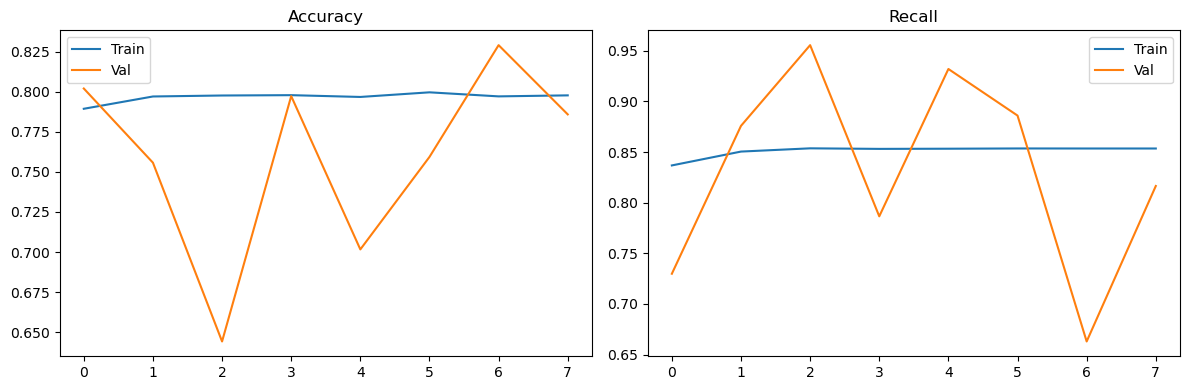

In [45]:
# trainig
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['recall'],     label='Train')
axes[1].plot(history.history['val_recall'], label='Val')
axes[1].set_title('Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

In [46]:
print(classification_report(y_test, y_pred_test, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.98      0.53      0.69      7422
        >50K       0.39      0.96      0.56      2336

    accuracy                           0.64      9758
   macro avg       0.69      0.75      0.62      9758
weighted avg       0.84      0.64      0.66      9758



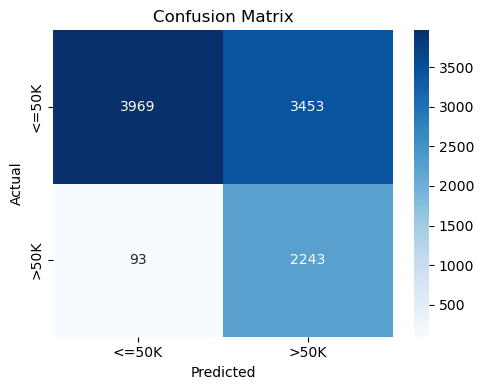

In [47]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [48]:
final_model = Sequential()
final_model.add(Input(shape=(X_train_res.shape[1],)))

final_model.add(Dense(128, activation='relu', kernel_initializer='he_normal'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.3))

final_model.add(Dense(64, activation='relu', kernel_initializer='he_normal'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.2))

final_model.add(Dense(32, activation='relu', kernel_initializer='he_normal'))
final_model.add(BatchNormalization())
final_model.add(Dropout(0.1))

final_model.add(Dense(1, activation='sigmoid'))

final_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]
)

final_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,633 (84.50 KB)

 Trainable params: 21,185 (82.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [49]:
es = EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True)

history = final_model.fit(
    X_train_res, y_train_res,
    epochs=100,               # increased
    batch_size=64,
    validation_data=(X_val_t, y_val),
    callbacks=[es],
    verbose=1
)

Epoch 1/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7813 - loss: 0.4613 - recall: 0.8326 - val_accuracy: 0.7480 - val_loss: 0.4707 - val_recall: 0.8866
Epoch 2/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8050 - loss: 0.4195 - recall: 0.8583 - val_accuracy: 0.7728 - val_loss: 0.4358 - val_recall: 0.8678
Epoch 3/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8117 - loss: 0.4080 - recall: 0.8630 - val_accuracy: 0.7765 - val_loss: 0.4361 - val_recall: 0.8614
Epoch 4/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8134 - loss: 0.4043 - recall: 0.8640 - val_accuracy: 0.7761 - val_loss: 0.4412 - val_recall: 0.8711
Epoch 5/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8168 - loss: 0.3989 - recall: 0.8684 - val_accuracy: 0.7811 - val_loss: 0.4375 - val_recall: 0.8684
Epoch 6/100
743/743 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8176 - loss: 0.3960 - recall: 0.8688 - val_accuracy: 0.7869 - val_loss: 0.4261 - val_recall: 0.863

In [50]:
# model evaluation
y_pred_test = np.where(final_model.predict(X_test_t) > 0.5, 1, 0)

y_pred_train = np.where(final_model.predict(X_train_res) > 0.5, 1, 0)
y_pred_val   = np.where(final_model.predict(X_val_t) > 0.5, 1, 0)

train_acc = accuracy_score(y_train_res, y_pred_train)
val_acc   = accuracy_score(y_val,y_pred_val)
test_acc  = accuracy_score(y_test,y_pred_test)

print(f"Train Accuracy      : {train_acc:.4f}")
print(f"Validation Accuracy : {val_acc:.4f}")
print(f"Test Accuracy       : {test_acc:.4f}")

305/305 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
1485/1485 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  
Train Accuracy      : 0.8381
Validation Accuracy : 0.7997
Test Accuracy       : 0.7884


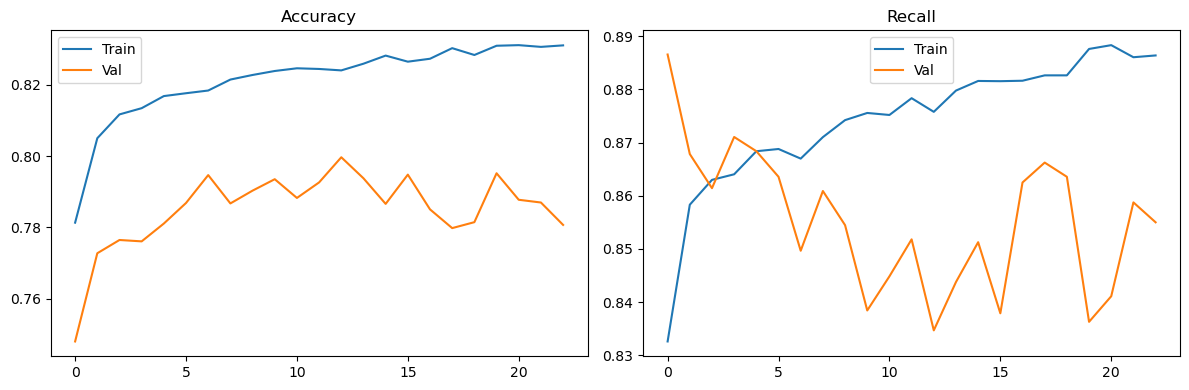

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['recall'],     label='Train')
axes[1].plot(history.history['val_recall'], label='Val')
axes[1].set_title('Recall')
axes[1].legend()

plt.tight_layout()
plt.show()

In [52]:
print(classification_report(y_test, y_pred_test, target_names=['<=50K', '>50K']))

              precision    recall  f1-score   support

       <=50K       0.94      0.77      0.85      7422
        >50K       0.54      0.83      0.65      2336

    accuracy                           0.79      9758
   macro avg       0.74      0.80      0.75      9758
weighted avg       0.84      0.79      0.80      9758



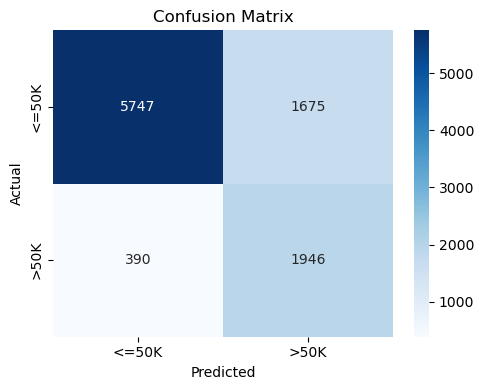

In [53]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
import pickle

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

final_model.save('adult_ann_model.keras')
print("Saved: preprocessor.pkl and adult_ann_model.keras")